# 读取文件

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 设置支持中文的字体（例如 SimHei），同时确保负号能正常显示
plt.rcParams['font.sans-serif'] = ['Times New Roman', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1) 读数据
df = pd.read_csv("../data/7.匹配时间/merged_output.csv")

print(df.head())

                    案号      裁判日期                                      当事人  \
0  （2016）浙0109民初16975号  2001/1/1   陈波波,王雷,华安财产保险股份有限公司安徽分公司宿州中心支公司灵璧营销服务部   
1   （2017）浙0109民初3106号  2001/1/1             施建康,姚路兴,中国人民财产保险股份有限公司杭州市分公司   
2   （2017）浙0109民初2322号  2001/1/1                周水娥；谭继明；信达财产保险股份有限公司浙江分公司   
3   （2017）浙0109民初2852号  2001/1/1  胡生羊；宋建国；杭州展铭钢铁有限公司；中国人民财产保险股份有限公司杭州市分公司   
4       （2002）绍刑初字第75号  2002/2/5                                       朱某   

  province city district specific_place  vehicle  death         lng  \
0      浙江省  杭州市      萧山区       横一线建一村路口      0.0    0.0  120.490977   
1      浙江省  杭州市      萧山区  瓜沥镇坎山工农村新农村地方      1.0    0.0  120.417430   
2      浙江省  杭州市      萧山区     临浦镇临浦电厂江塘处      1.0    0.0  120.256051   
3      浙江省  杭州市      萧山区   青六线杨家桥南300米处      1.0    0.0  120.261186   
4      浙江省  绍兴市      柯桥区   104国道绍兴县柯桥地段      2.0    1.0  120.496143   

         lat         case_dt_hour  
0  30.300890  2016-06-30 09:00:00  
1  30.183977  2013-12-28 15:00:00  
2 

# 解析时间

In [6]:
# 2) 解析时间字段
df["case_dt_hour"] = pd.to_datetime(df["case_dt_hour"], errors="coerce")
df = df.dropna(subset=["case_dt_hour"]).copy()

# ✅ 只保留 2020-12-31（含）及之前的数据
# df = df[df["case_dt_hour"] <= pd.Timestamp("2020-12-31 23:59:59")].copy()

# ✅ 只保留 2000-01-01（含）到 2020-12-31（含）的数据
start = pd.Timestamp("2000-01-01 00:00:00")
end   = pd.Timestamp("2020-12-31 23:59:59")
df = df[df["case_dt_hour"].between(start, end, inclusive="both")].copy()

# 3) 抽取 年/月/小时
df["year"] = df["case_dt_hour"].dt.year
df["month"] = df["case_dt_hour"].dt.month
df["hour"] = df["case_dt_hour"].dt.hour

# 4) 计数（补齐缺失的月份/小时，保证 1-12、0-23 都有柱子）
year_cnt  = df["year"].value_counts().sort_index()
month_cnt = df["month"].value_counts().sort_index().reindex(range(1, 13), fill_value=0)
hour_cnt  = df["hour"].value_counts().sort_index().reindex(range(0, 24), fill_value=0)

In [8]:
year_cnt

year
2000        74
2001       105
2002       172
2003       210
2004       290
2005       420
2006       737
2007      1348
2008      2029
2009      3885
2010      7046
2011     16912
2012     59242
2013    168528
2014    233159
2015    240176
2016    197560
2017     43782
2018     26831
2019    130071
2020     99710
Name: count, dtype: int64

# 绘图

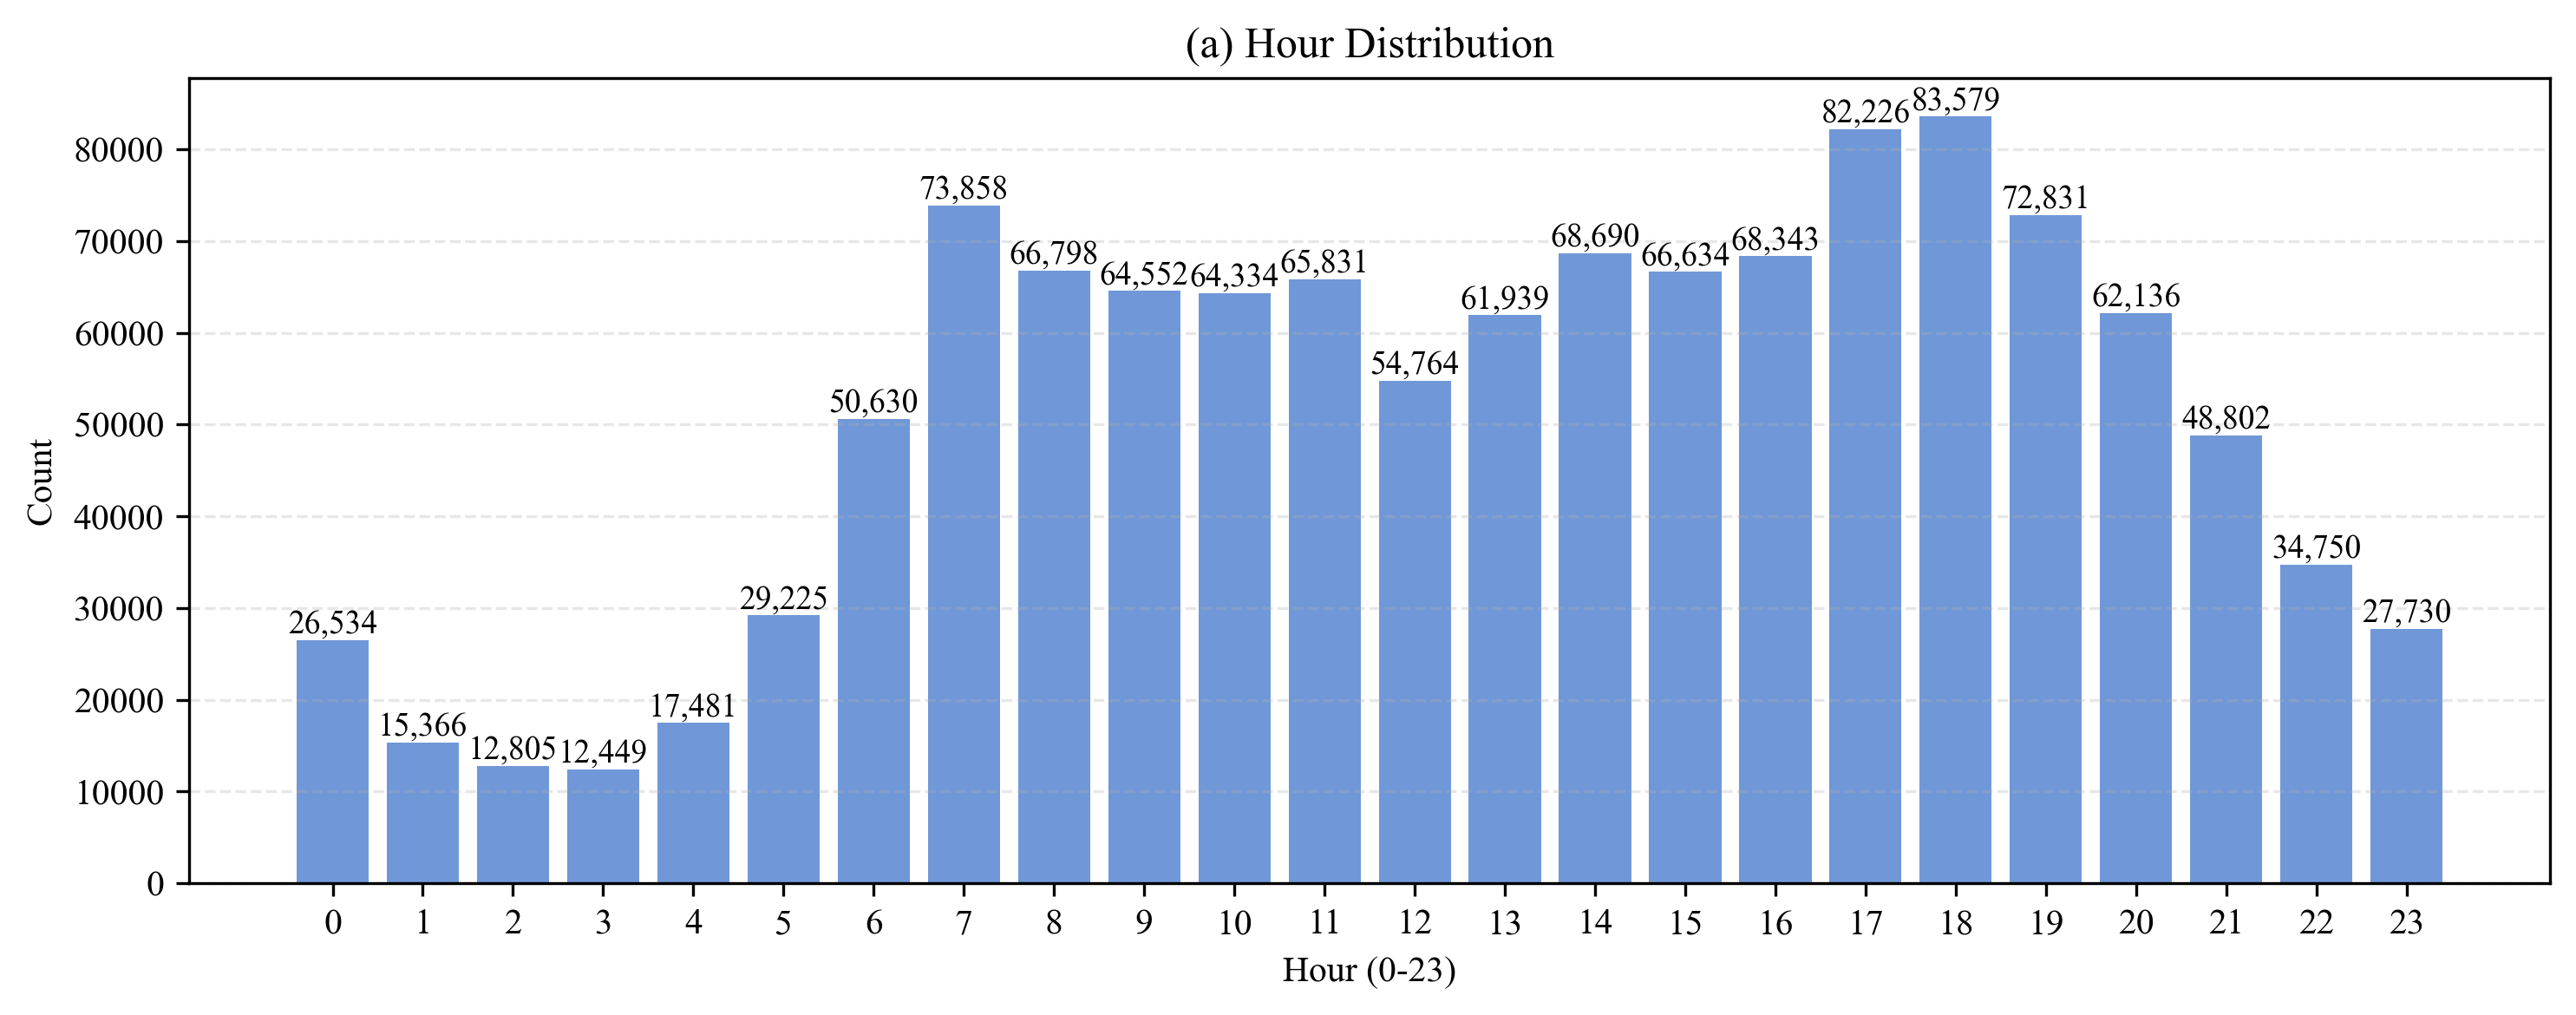

In [12]:
# -----------------------------
# (a) 小时分布
# -----------------------------
x = hour_cnt.index.tolist()
y = hour_cnt.values.tolist()

fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
ax.bar(x, y, color="#7098d8")

ax.set_xlabel("Hour (0-23)")
ax.set_ylabel("Count")
ax.set_title("(a) Hour Distribution")
ax.grid(axis="y", linestyle="--", alpha=0.3)

for xi, yi in zip(x, y):
    if yi > 0:
        ax.text(xi, yi, f"{yi:,}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()

plt.savefig('../data/figure/time_hour.png', dpi=300,
            bbox_inches='tight', # 自动裁剪掉周围多余的白边
            pad_inches=0.1)       # 裁剪后保留一点点边距


plt.show()



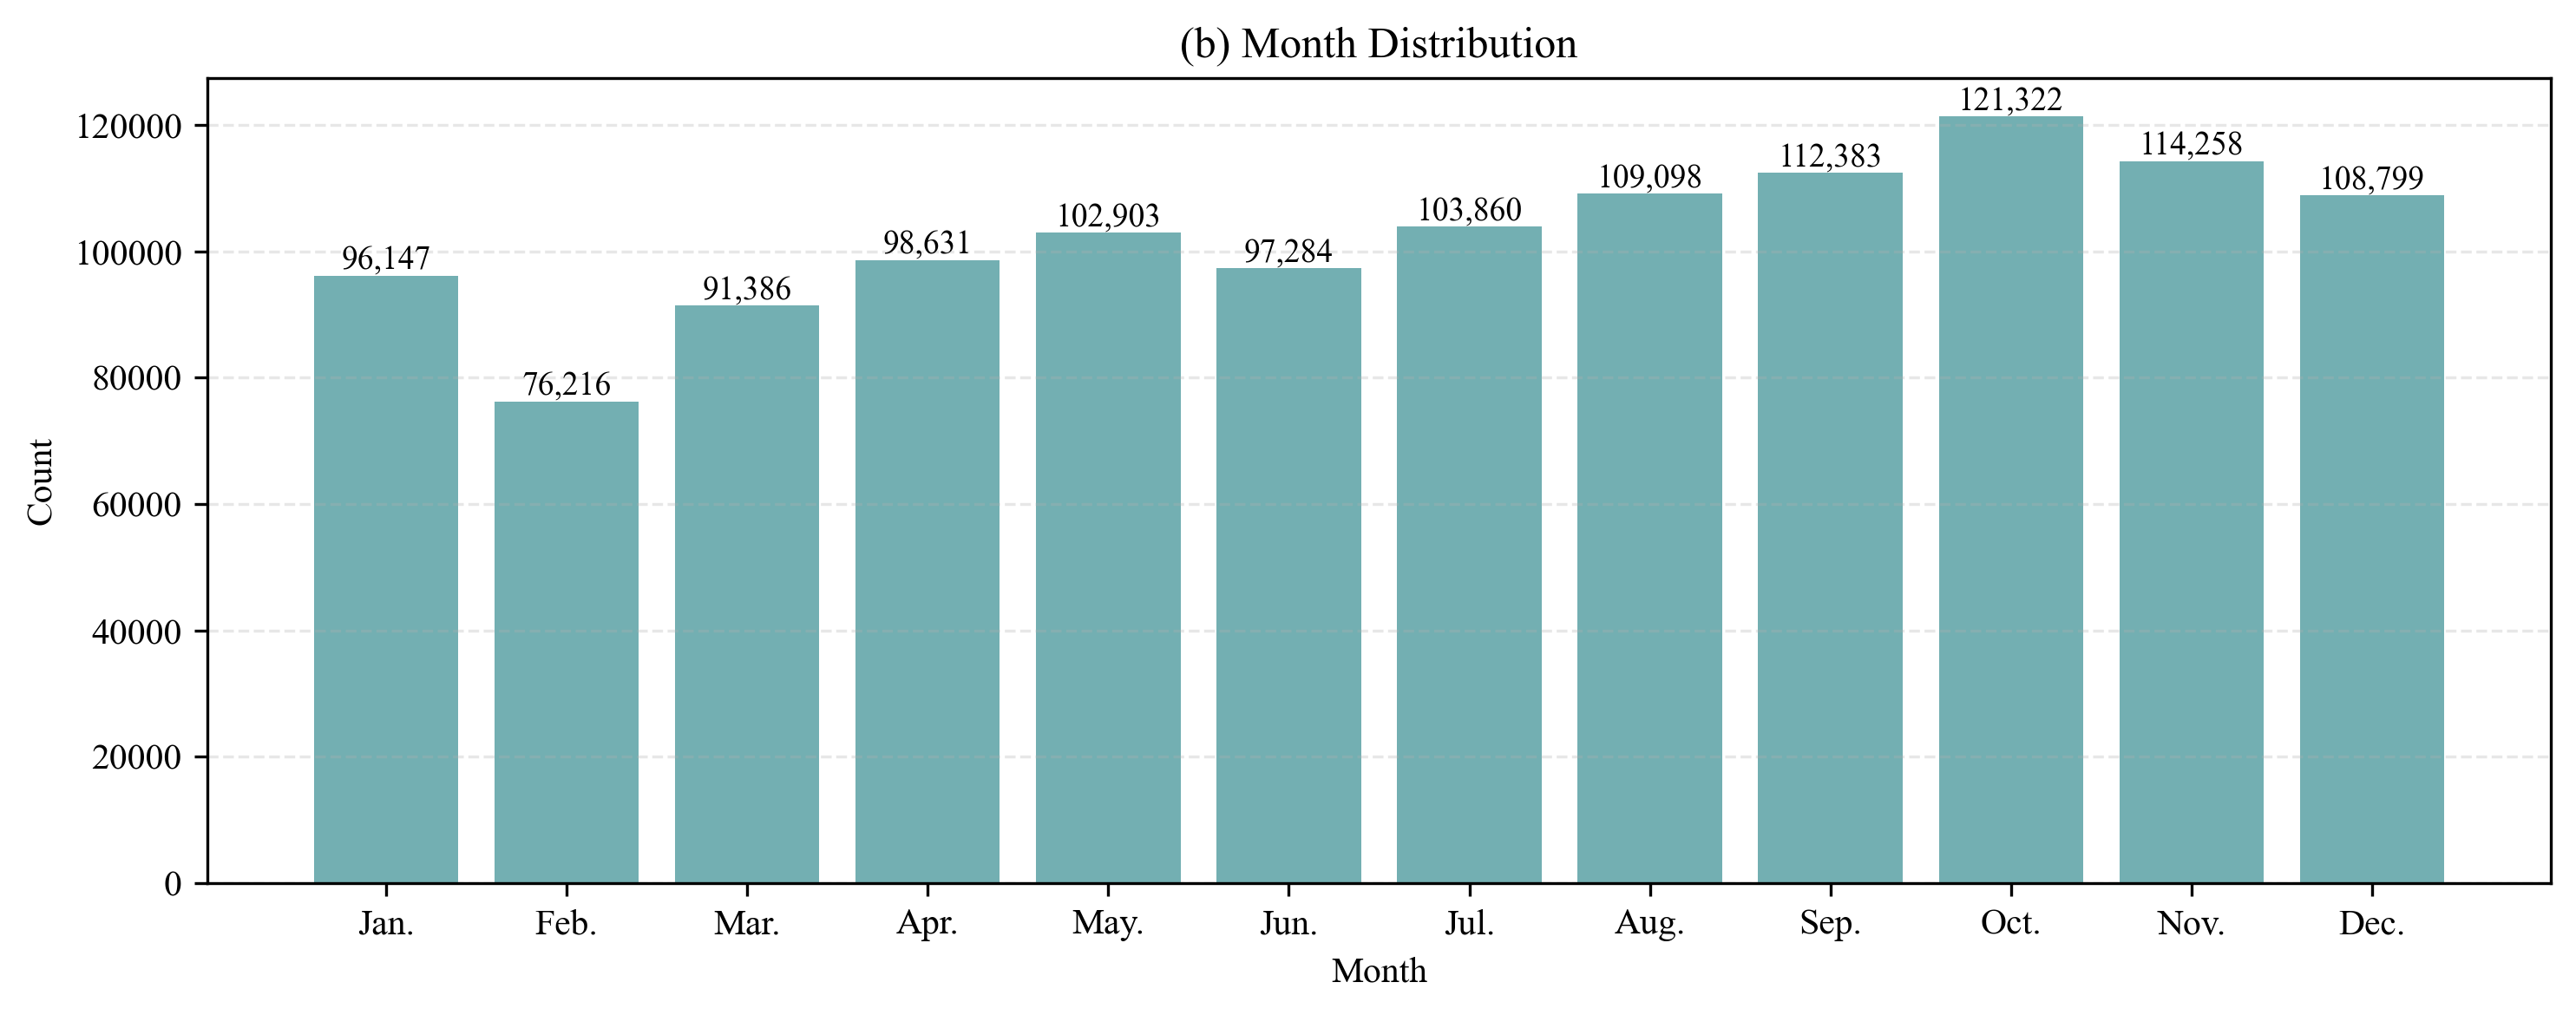

In [14]:
# -----------------------------
# (b) 月份分布（Jan. Feb. ...）
# -----------------------------
month_map = {
    1: "Jan.", 2: "Feb.", 3: "Mar.", 4: "Apr.", 5: "May.", 6: "Jun.",
    7: "Jul.", 8: "Aug.", 9: "Sep.", 10: "Oct.", 11: "Nov.", 12: "Dec."
}

x = month_cnt.index.tolist()
y = month_cnt.values.tolist()

fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
ax.bar(x, y, color="#73afb2")

ax.set_xlabel("Month")
ax.set_ylabel("Count")
ax.set_title("(b) Month Distribution")
ax.grid(axis="y", linestyle="--", alpha=0.3)

for xi, yi in zip(x, y):
    if yi > 0:
        ax.text(xi, yi, f"{yi:,}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([month_map.get(m, str(m)) for m in x])  # 核心：把 1-12 显示成 Jan. Feb...
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig('../data/figure/time_month.png', dpi=300,
            bbox_inches='tight', # 自动裁剪掉周围多余的白边
            pad_inches=0.1)       # 裁剪后保留一点点边距

plt.show()


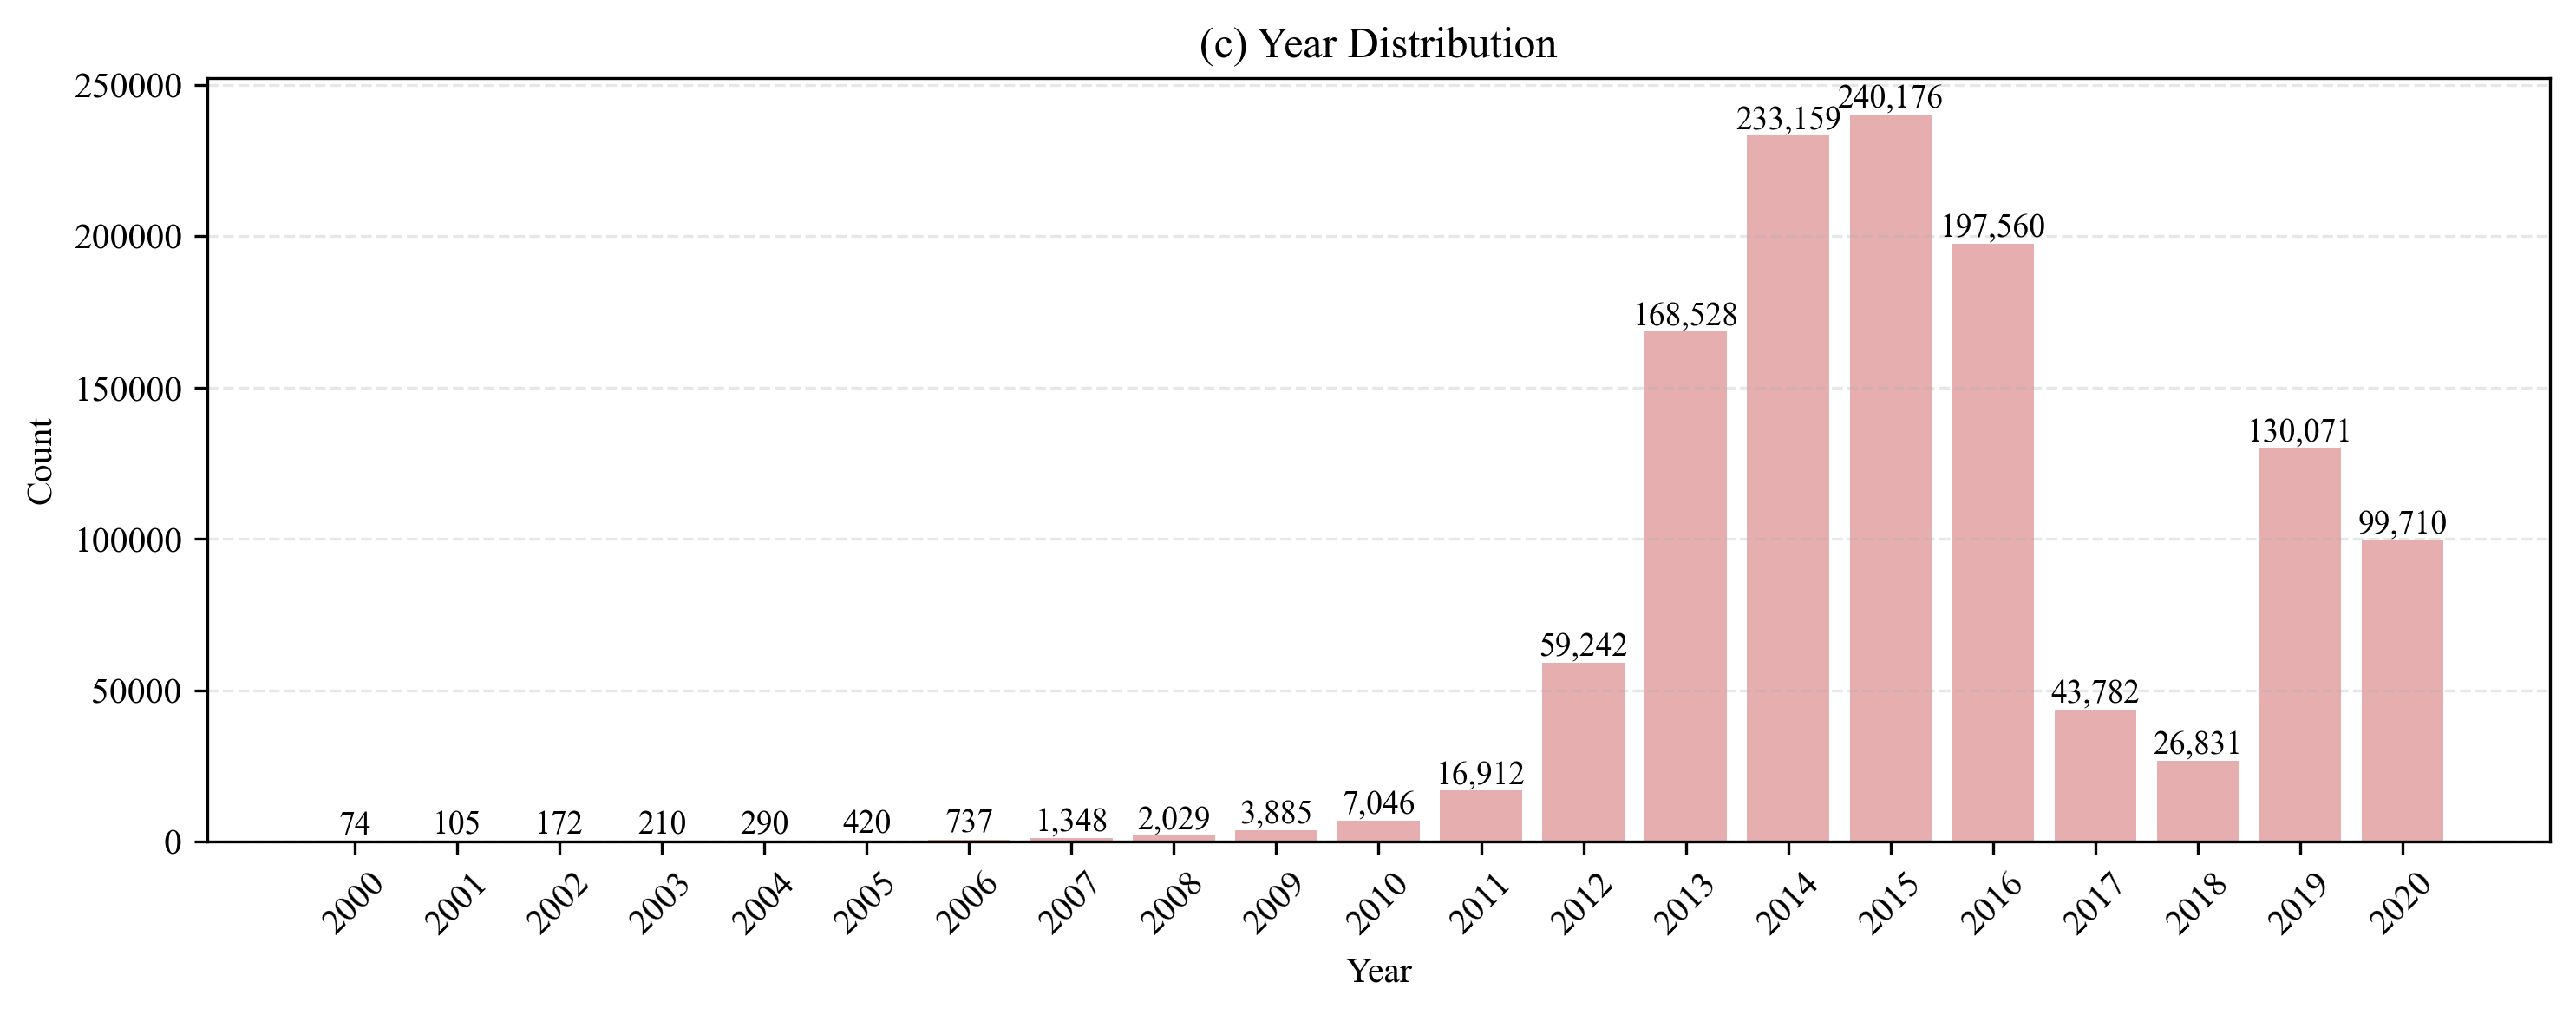

In [17]:
# -----------------------------
# (c) 年份分布
# -----------------------------
x = year_cnt.index.tolist()
y = year_cnt.values.tolist()

fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
ax.bar(x, y, color="#e6aeaf")

ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.set_title("(c) Year Distribution")
ax.grid(axis="y", linestyle="--", alpha=0.3)

for xi, yi in zip(x, y):
    if yi > 0:
        ax.text(xi, yi, f"{yi:,}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

plt.savefig('../data/figure/time_year.png', dpi=300,
            bbox_inches='tight', # 自动裁剪掉周围多余的白边
            pad_inches=0.1)       # 裁剪后保留一点点边距
plt.show()
